In [52]:
PROJECT_HOME = 'ABSOLUTE_PATH_TO_THE_ROOT'

In [53]:
from typing import Optional
import os
import json
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt, axes, patches

In [54]:
def read_json(path: str) -> pd.DataFrame:
    with open(path, "r") as file:
        data = json.load(file)
    cols = data["columns"]
    data = data["data"]
    data = [dict(zip(cols, datum)) for datum in data]
    return pd.DataFrame.from_records(data)

In [ ]:
BASE_DIR = 'ABSOLUTE_PATH_TO_THE_PROJECT'

In [ ]:
def get_elec_file_dir(data_key: str):
    return os.path.join(BASE_DIR, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_electricelectricity-normalized_plots")

In [56]:
def get_df_by_key(key, file_idx: int = 0, file_dir_getter: Optional[callable] = None) -> pd.DataFrame:
    file_dir_getter = file_dir_getter or get_elec_file_dir
    file_dir = file_dir_getter(key)
    filename = os.listdir(file_dir)[file_idx]
    return read_json(os.path.join(file_dir, filename))

In [146]:
def print_prediction(ax: axes.Axes, data: pd.DataFrame, region_color: str = "blue"):
    ax.fill_between(
        data["step"],
        data["pi_low"],
        data["pi_high"],
        alpha=0.25,
        color=region_color,
    )
    if "fc_y_hat" in data.columns:
        ax.plot(
            data["step"],
            data["fc_y_hat"],
            label=f"Y Hat",
            color="red",
            linestyle="dashed",
            linewidth=4
        )
    if "fc_pi_low" in data.columns:
        ax.fill_between(
            data["step"],
            data["fc_pi_low"],
            data["fc_pi_high"],
            alpha=0.15,
            color="red",
        )

In [147]:
def plot_data(
    ax: plt.Axes,
    data: pd.DataFrame,
    tick_step: int = 100,
    labels_kw: Optional[dict] = None,
    x_ticks: Optional[list] = None,
    y_ticks: Optional[list] = None,
):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid()
    ax.plot(
        data["step"],
        data["y_real"],
        label=f"Real Y",
        color="black",
        linestyle="dashed",
        linewidth=4,
    )
    print_prediction(ax, data)
    labels_kw = {"fontsize": 30} if labels_kw is None else labels_kw
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_ticks, **labels_kw)

    if x_ticks is None:
        last_step = int(data.iloc[-1]["step"]) // tick_step * tick_step
        first_step = (int(data.iloc[0]["step"]) // tick_step + 1) * tick_step
        x_ticks = list(range(first_step, last_step + 1, tick_step))

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, **labels_kw)

    ax.set_xlim(data.iloc[0]["step"], data.iloc[-1]["step"])

    return ax

In [164]:
start_step, end_step = 0, 1000000000


def filter_df(df: pd.DataFrame, start: int | None = None, end: int = None):
    start = start if start is not None else start_step
    end = end if end is not None else end_step
    return df[(df["step"] > start) & (df["step"] < end)]

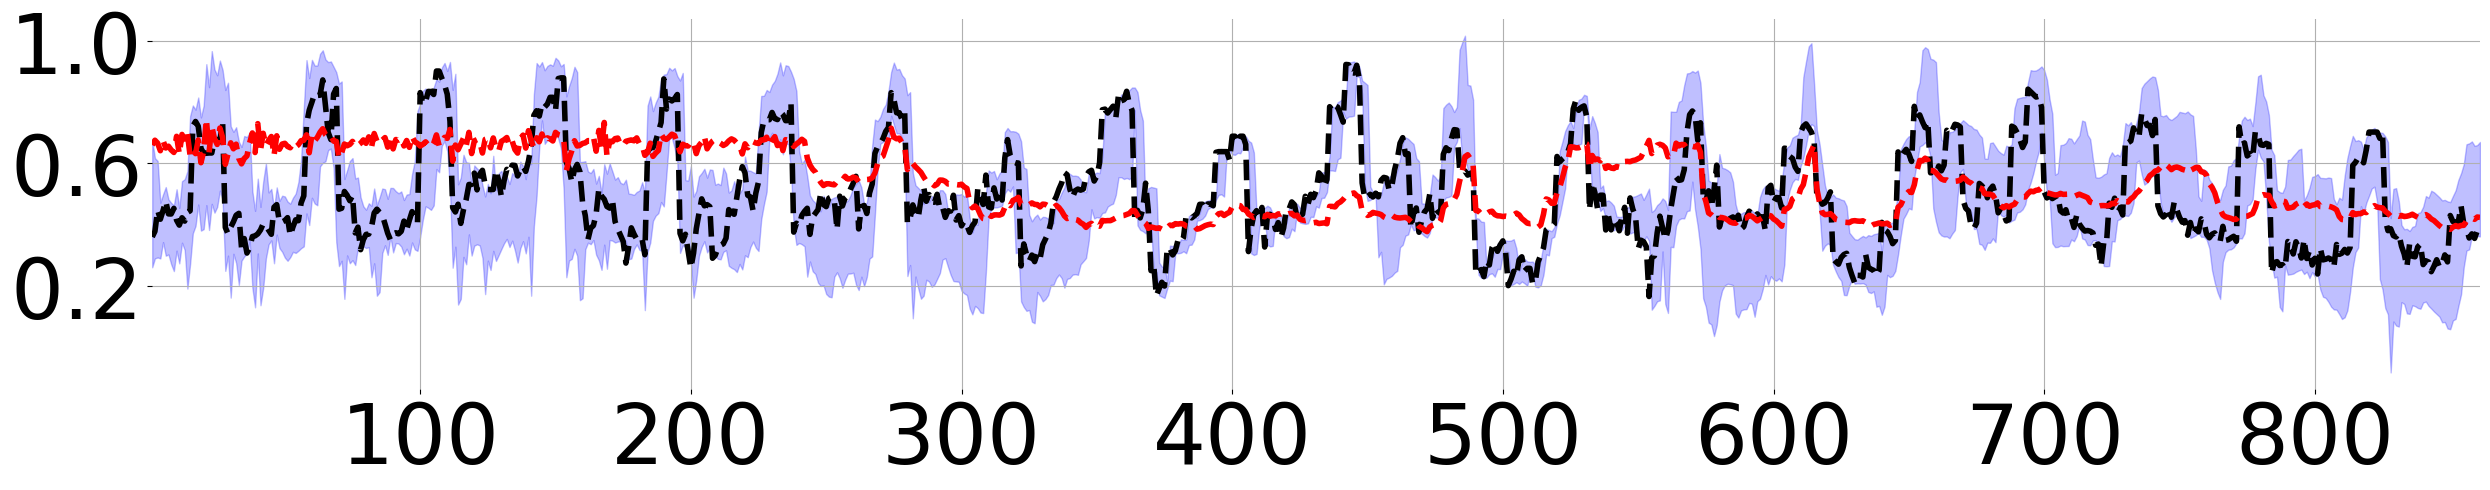

In [165]:
key = "darts_forest_dist_match_enbPI_electric_s30_160126_163750"
key = "darts_forest_enbpi_enbPI_electric_s30_290126_145206"
key = "darts_forest_eps_pred_hopfield_enbPI_electric_s30_290126_145234"
key = "darts_forest_nextcp_enbPI_electric_s30_290126_145300"
key = "darts_forest_spic_enbPI_electric_s20_200126_195456"
key = "darts_forest_conf_default_enbPI_electric_s30_290126_145716"
key = "darts_forest_conf_default_plus_recent_enbPI_electric_s30_290126_145724"
key = "darts_forest_kowcpi_enbPI_electric_s30_290126_150148"

result_df = get_df_by_key(key)

fig, ax = plt.subplots(figsize=(25, 5))
ax = plot_data(ax, filter_df(result_df), y_ticks=[0.2, 0.6, 1.0], labels_kw={"fontsize": 60})
fig.tight_layout()
fig.savefig(f"{key}.pdf")

In [166]:
def plot_diff(data1: pd.DataFrame, data2: pd.DataFrame, circles=None):
    fig, ax = plt.subplots(figsize=(25, 9))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid()
    ax.plot(
        data1["step"],
        data1["y_real"],
        label=f"Real Y",
        color="black",
        linestyle="dashed",
    )
    ax.fill_between(
        data1["step"],
        data1["pi_low"],
        data1["pi_high"],
        alpha=0.8,
        color="#f09c37",
        label="DistMatch",
    )
    ax.fill_between(
        data2["step"],
        data2["pi_low"],
        data2["pi_high"],
        alpha=0.8,
        color="#b5b5b5",
        label="SPCI",
    )
    y_ticks = [0.2, 0.6, 1.0]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticks, fontsize=60)

    circles = circles if circles is not None else []
    for args in circles:
        circle = patches.Ellipse(*args, color="#A00005", fill=False, linewidth=3)
        ax.add_patch(circle)

    step_size = 50

    last_step = int(data1.iloc[-1]["step"]) // step_size * step_size
    first_step = (int(data1.iloc[0]["step"]) // step_size + 1) * step_size
    x_tick_labels = x_ticks = list(range(first_step, last_step + 1, step_size))
    # x_ticks = data1['step'].values[::step_size]
    # x_tick_labels = [i * step_size for i in range(len(x_ticks))]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels, fontsize=60)

    ax.set_xlim(data1.iloc[0]["step"], data1.iloc[-1]["step"])
    fig.legend(fontsize=60,  bbox_to_anchor=(0.9, 1.158), ncol=3)
    fig.tight_layout()
    return fig

In [167]:
def extract_regions(df: pd.DataFrame, regions: list):
    df = pd.concat([filter_df(df, start, stop) for (start, stop) in regions])
    df["step"] = np.arange(0, len(df))
    return df

In [168]:
key1 = "darts_forest_dist_match_enbPI_electric_s30_160126_163750"
key2 = "darts_forest_spic_enbPI_electric_s20_200126_195456"

file_dir = get_elec_file_dir(key1)
filename = os.listdir(file_dir)[0]
result1_df = read_json(os.path.join(file_dir, filename))

file_dir = get_elec_file_dir(key2)
filename = os.listdir(file_dir)[2]
result2_df = read_json(os.path.join(file_dir, filename))

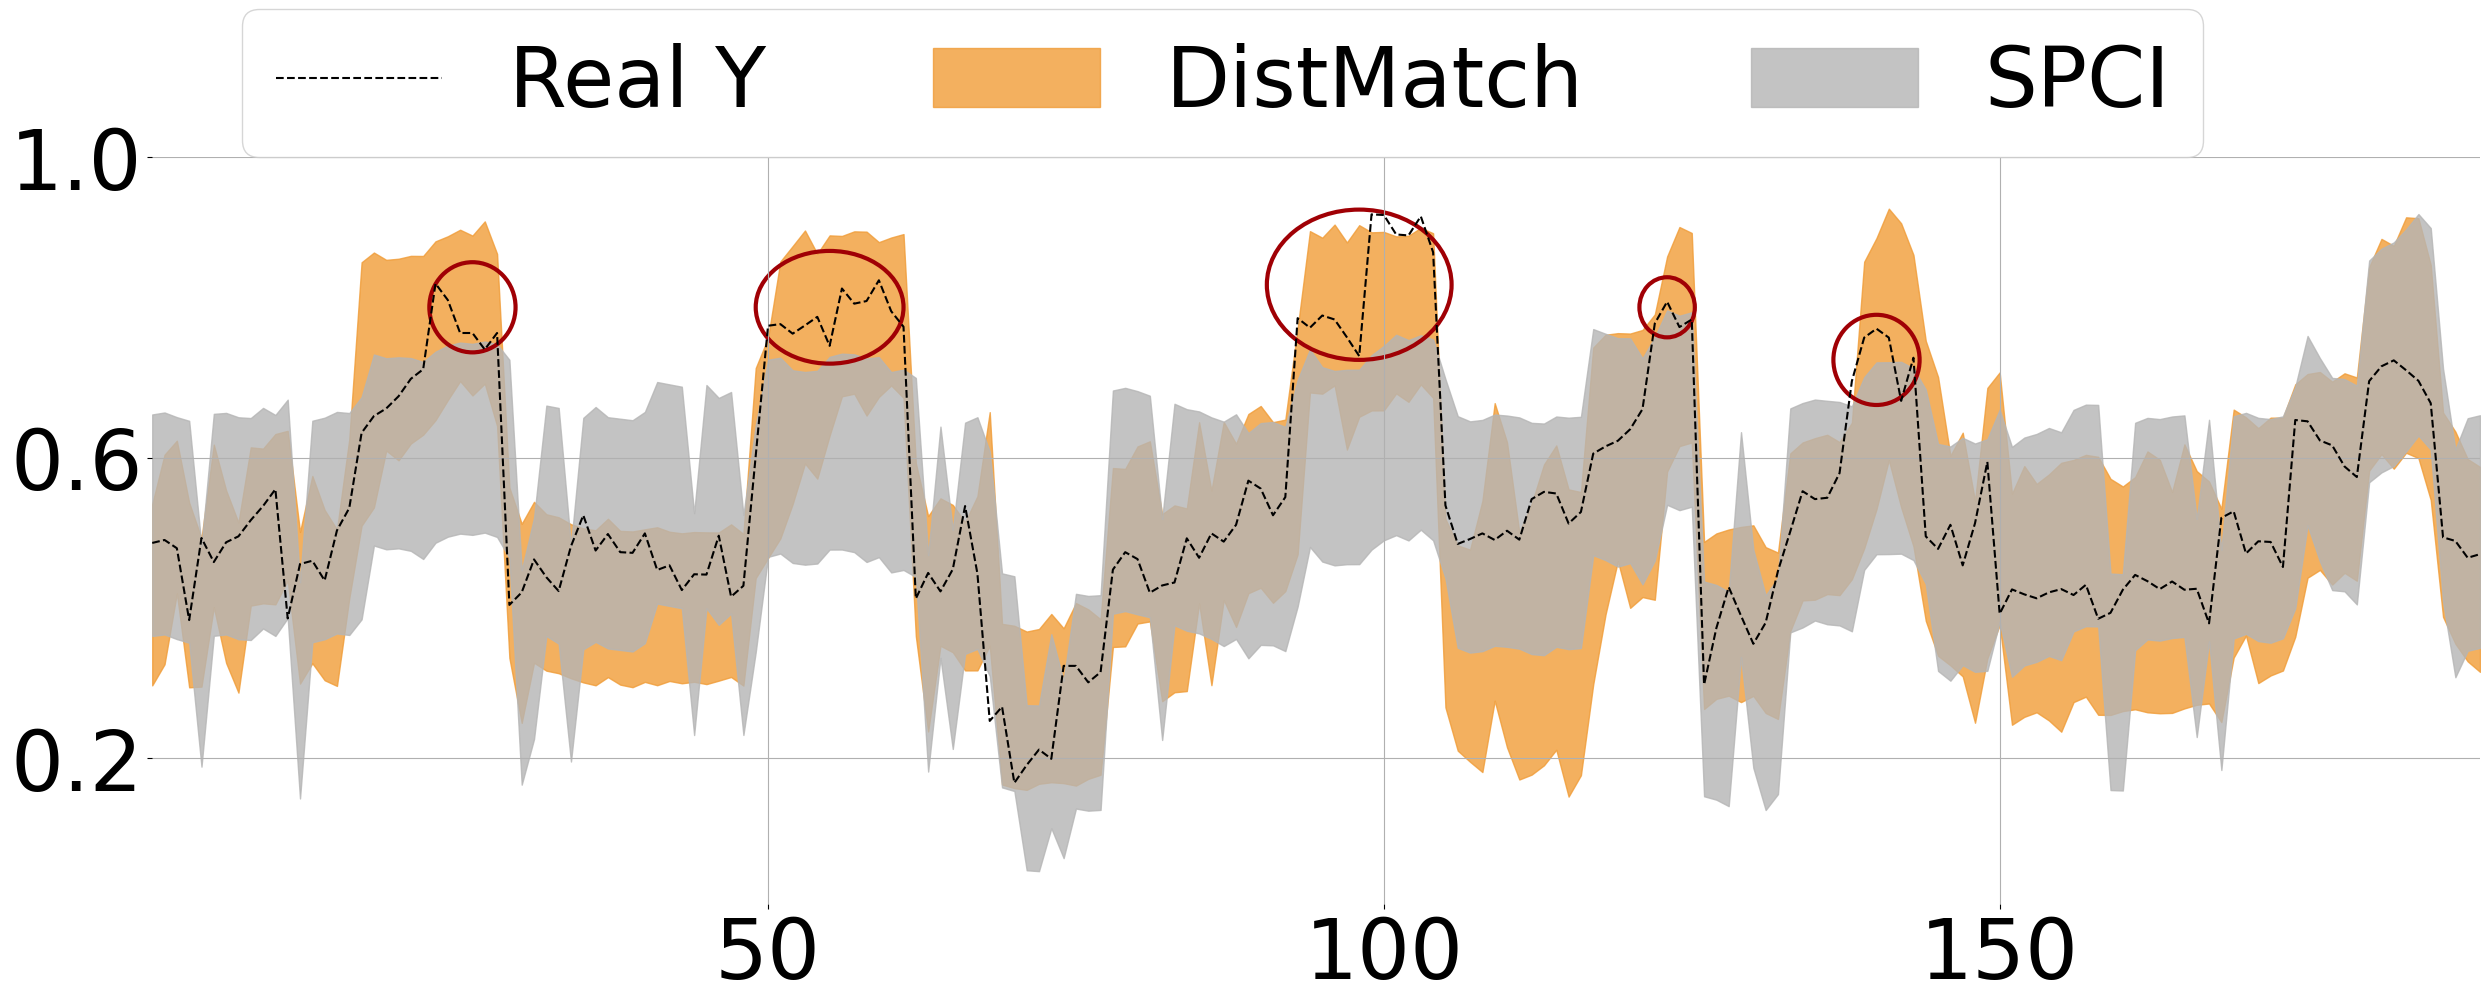

In [169]:
regions = [(250, 300), (350, 380), (420, 460), (520, 530), (555, 620)]

circles = [
    [(26, 0.8), 7, 0.12],
    [(55, 0.8), 12, 0.15],
    [(98, 0.83), 15, 0.2],
    [(123, 0.8), 4.5, 0.08],
    [(140, 0.73), 7, 0.12],
]
fig = plot_diff(
    extract_regions(result1_df, regions),
    extract_regions(result2_df, regions),
    circles=circles,
)
fig.savefig(f"dist_vs_spci.pdf", bbox_inches='tight')

In [170]:
def plot_with_baselines(src_data: pd.DataFrame, baselines: pd.DataFrame, baseline_titles: list):
    n_baselines = len(baselines)
    tick_step = len(src_data) // n_baselines
    x_ticks = src_data.iloc[0]['step'] + np.arange(1, n_baselines) * tick_step
    x_ticks = x_ticks.astype(int)

    sep_y = 0.47

    fig = plt.figure(figsize=(25, 10), layout="constrained")
    spec = fig.add_gridspec(2, n_baselines)

    src_ax = fig.add_subplot(spec[0, :])
    src_ax.set_title("DistMatch", fontsize=60)

    src_ax = plot_data(src_ax, src_data, labels_kw={"fontsize": 45}, y_ticks=[0.2, 0.6, 1.0], x_ticks=x_ticks)

    # Horizontal line between top and bottom axes
    sep_color = "#b7b7b7"
    h_sep_line = plt.Line2D([0, 1], [sep_y, sep_y], transform=fig.transFigure, color=sep_color, linewidth=2)
    fig.add_artist(h_sep_line)

    y_lim = src_ax.get_ylim()
    y_ticks = src_ax.get_yticks()

    start_step = src_data.iloc[0]['step']
    end_step = src_data.iloc[-1]['step']

    data_step = int((end_step - start_step) / n_baselines)

    baseline_axs = [fig.add_subplot(spec[1, i]) for i in range(n_baselines)]
    
    for idx, (ax, data) in enumerate(zip(baseline_axs, baselines)):
        data = filter_df(data, start_step + idx * data_step, start_step + (idx + 1) * data_step)
        ax = plot_data(ax, data, labels_kw={"fontsize": 45}, y_ticks=[0.2, 0.6, 1.0])
        ax.set_title(baseline_titles[idx], fontsize=60)
        ax.set_ylim(y_lim)
        ax.set_yticks(y_ticks)
        ax.set_xticks([])
        
        if idx == 0:
            continue

        ax.set_yticklabels([])

        l_offset = 0.046
        r_offset = 0.0025
        v_sep_pos = l_offset + (idx) / n_baselines * (1 - l_offset - r_offset)
        v_sep_line = plt.Line2D([v_sep_pos, v_sep_pos], [0, sep_y], transform=fig.transFigure, color=sep_color, linewidth=2)
        fig.add_artist(v_sep_line)

    
    fig.tight_layout()

    return fig

/tmp/ipykernel_3482538/1624157617.py:52: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


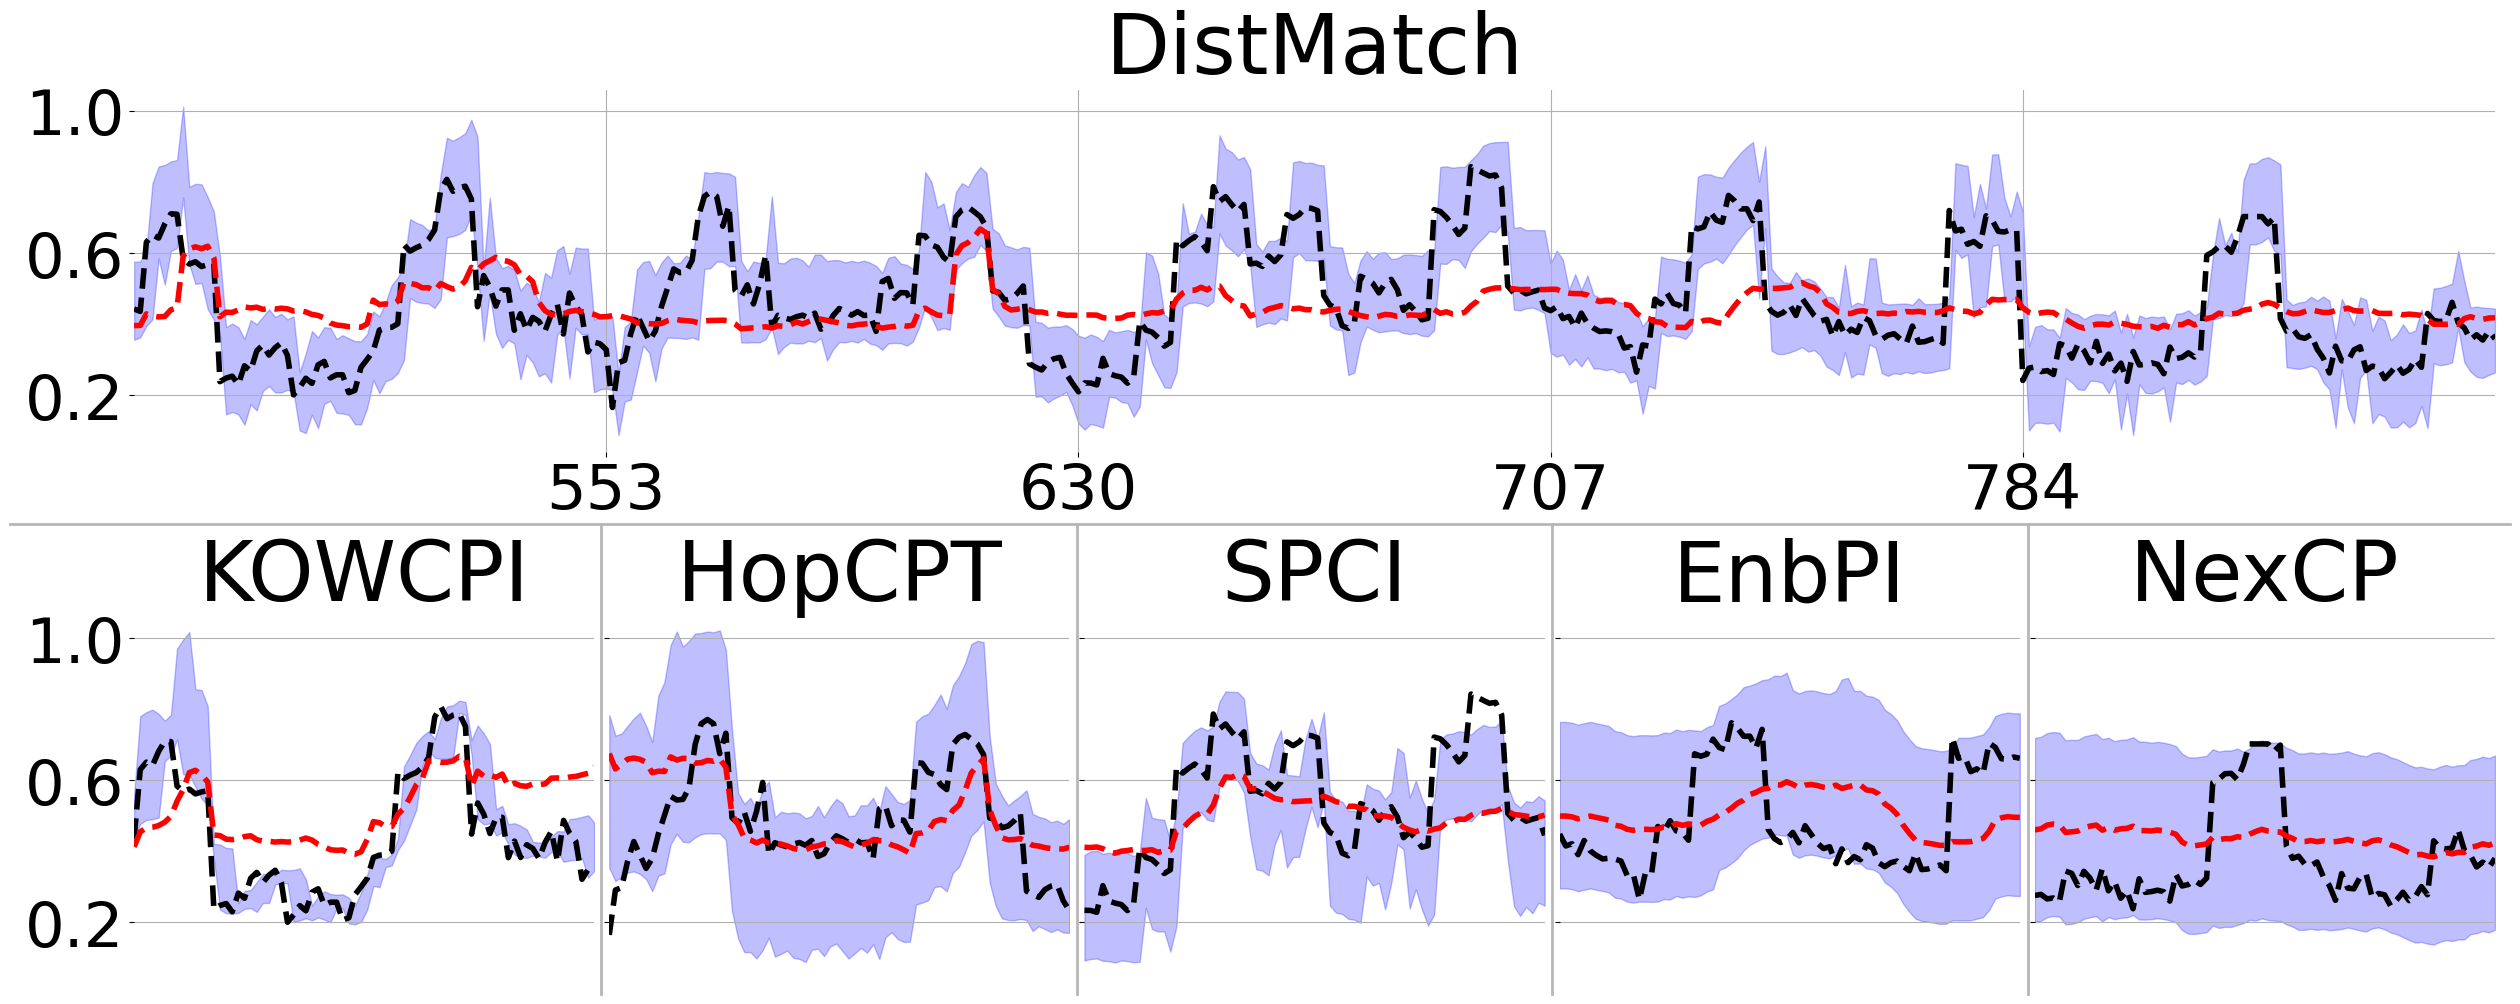

In [175]:
src_key = "darts_forest_dist_match_enbPI_electric_s30_220126_172308"
baseline_keys = {
    "KOWCPI": "darts_forest_kowcpi_enbPI_electric_s30_290126_150148",
    "HopCPT": "darts_forest_eps_pred_hopfield_enbPI_electric_s30_290126_145234",
    "SPCI": "darts_forest_spic_enbPI_electric_s30_290126_144413",
    "EnbPI": "darts_forest_enbpi_enbPI_electric_s30_290126_145206",
    "NexCP": "darts_forest_nextcp_enbPI_electric_s30_290126_145300",
}

baseline_plot_start_step = 475
src_df = filter_df(get_df_by_key(src_key), baseline_plot_start_step)

baseline_dfs = [filter_df(get_df_by_key(key), baseline_plot_start_step) for key in baseline_keys.values()]
baseline_titles = [name for name in baseline_keys.keys()]

fig = plot_with_baselines(src_df, baseline_dfs, baseline_titles)
fig.savefig('dist_w_baselines_elec_forest.pdf')
fig.show()

In [ ]:
def get_nflx_file_dir(data_key: str):
    return os.path.join(BASE_DIR, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_stockNFLX_plots")

In [ ]:
key = "darts_tcn_dist_match_stock_nflx_280525_144732"
key = "darts_tcn_eps_pred_hopfield_stock_nflx_200625_163750"
key = "darts_tcn_spic_stock_nflx_290525_150108"
key = "darts_tcn_enbpi_stock_nflx_200625_171957"
key = "darts_tcn_nextcp_stock_nflx_200625_172037"
key = "darts_tcn_conf_default_stock_nflx_250625_164242"
key = "darts_tcn_conf_default_plus_recent_stock_nflx_260625_120503"

result_df = get_df_by_key(key, file_dir_getter=get_nflx_file_dir)

fig, ax = plt.subplots(figsize=(25, 5))

ax = plot_data(ax, filter_df(result_df, 4260, 4300), y_ticks=[950, 965, 980], tick_step=10, labels_kw={"fontsize": 60})
fig.tight_layout()
# fig.savefig(f"{key}.pdf")

In [ ]:
def get_pems_file_dir(data_key: str):
    return os.path.join(BASE_DIR, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_pems2022_01_plots")

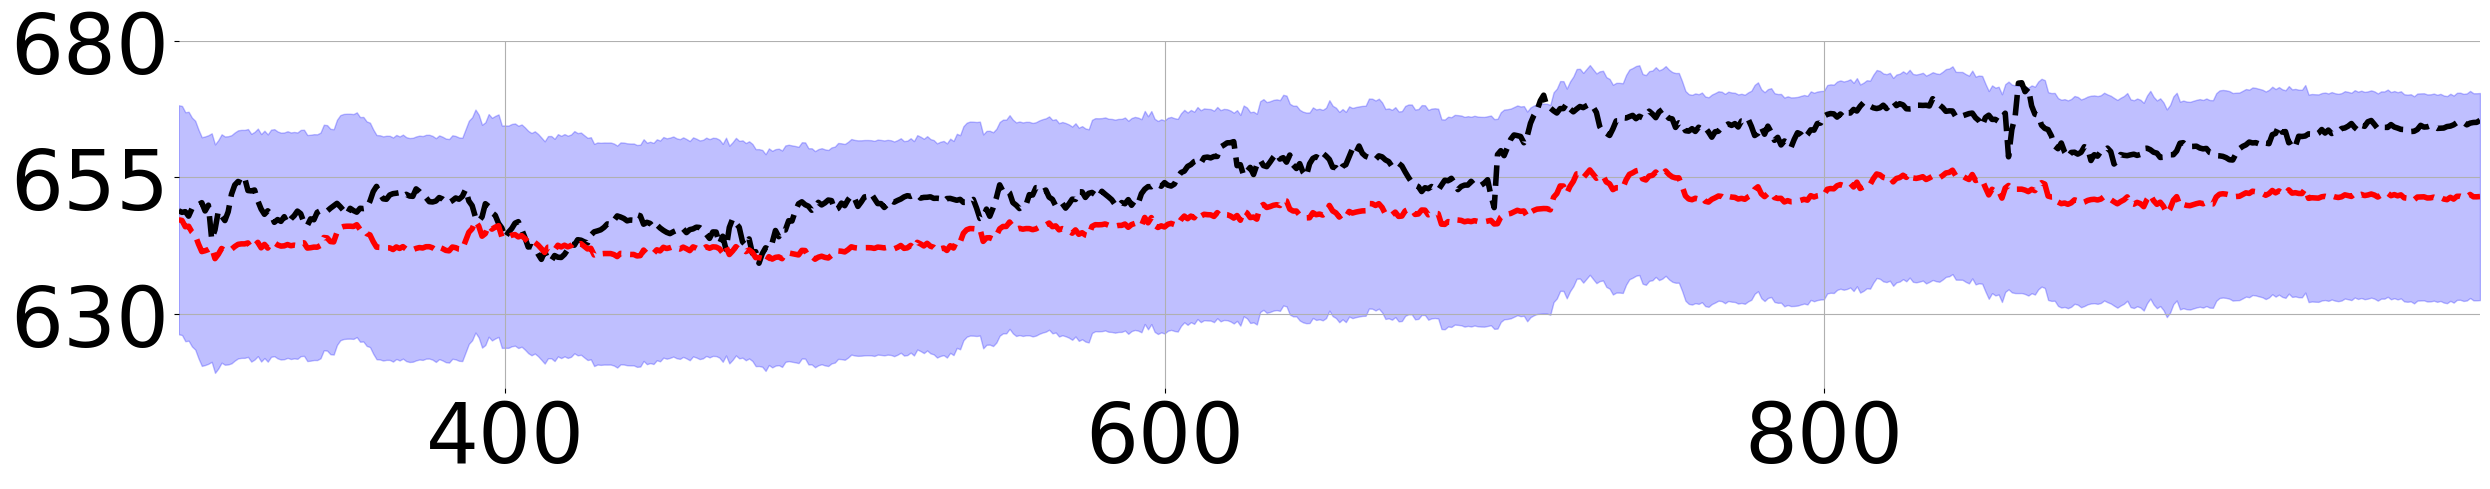

In [ ]:
key = "darts_lightgbm_dist_match_stock_meta_5m_s20_290126_113348"
key = "darts_lightgbm_eps_pred_hopfield_stock_meta_5m_s30_280126_212655"
key = "darts_lightgbm_spic_stock_meta_5m_s30_280126_212528"
key = "darts_lightgbm_enbpi_stock_meta_5m_s30_280126_212625"
key = "darts_lightgbm_nextcp_stock_meta_5m_s30_280126_212657"
key = "darts_lightgbm_conf_default_stock_meta_5m_s30_290126_174700"
key = "darts_lightgbm_conf_default_plus_recent_stock_meta_5m_s30_290126_174712"
key = "darts_lightgbm_kowcpi_stock_meta_5m_s30_290126_174406"

result_df = get_df_by_key(key, file_dir_getter=get_meta_file_dir)

fig, ax = plt.subplots(figsize=(25, 5))

# ax = plot_data(ax, filter_df(result_df, 800, 1300), y_ticks=[180, 185, 190], tick_step=150, labels_kw={"fontsize": 60})
ax = plot_data(ax, filter_df(result_df, 300, 1000), y_ticks=[630, 655, 680], tick_step=200, labels_kw={"fontsize": 60})
fig.tight_layout()
fig.savefig(f"{key}.pdf")

In [ ]:
def get_rain_file_dir(data_key: str):
    return os.path.join(BASE_DIR, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_raindaily_weather_plots")

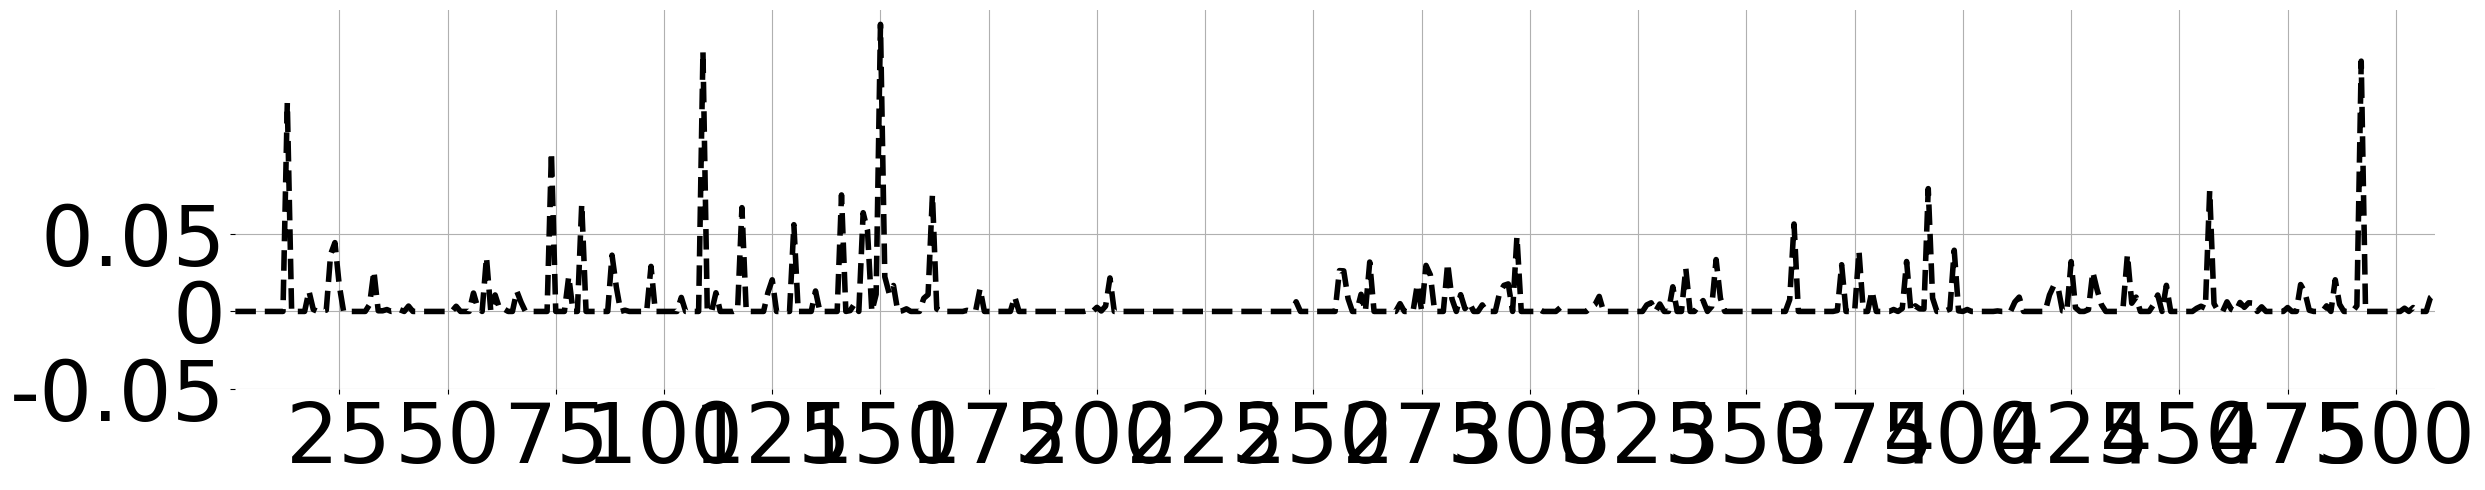

In [ ]:
key = "darts_tcn_dist_match_rain_s20_040825_172051"
key = "darts_tcn_eps_pred_hopfield_rain_s100_040825_171823"
key = "darts_tcn_spic_rain_s100_040825_164053"
key = "darts_tcn_enbpi_rain_s10_040825_173831"
key = "darts_tcn_nextcp_rain_s10_040825_174526"
key = "darts_tcn_conf_default_rain_s10_040825_175404"
key = "darts_tcn_conf_default_plus_recent_rain_s10_040825_175412"

result_df = get_df_by_key(key, file_idx=2, file_dir_getter=get_rain_file_dir)

fig, ax = plt.subplots(figsize=(25, 5))


# ax = plot_data(ax, filter_df(result_df, 250, 350), y_ticks=[-0.05, 0, 0.05], tick_step=25, labels_kw={"fontsize": 60})
ax = plot_data(ax, filter_df(result_df, 0, 1000), y_ticks=[-0.05, 0, 0.05], tick_step=25, labels_kw={"fontsize": 60})
fig.tight_layout()
# fig.savefig(f"{key}.pdf")

In [192]:
def get_synthetic_file_dir(data_key: str):
    return os.path.join(PROJECT_HOME, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_data_plots")

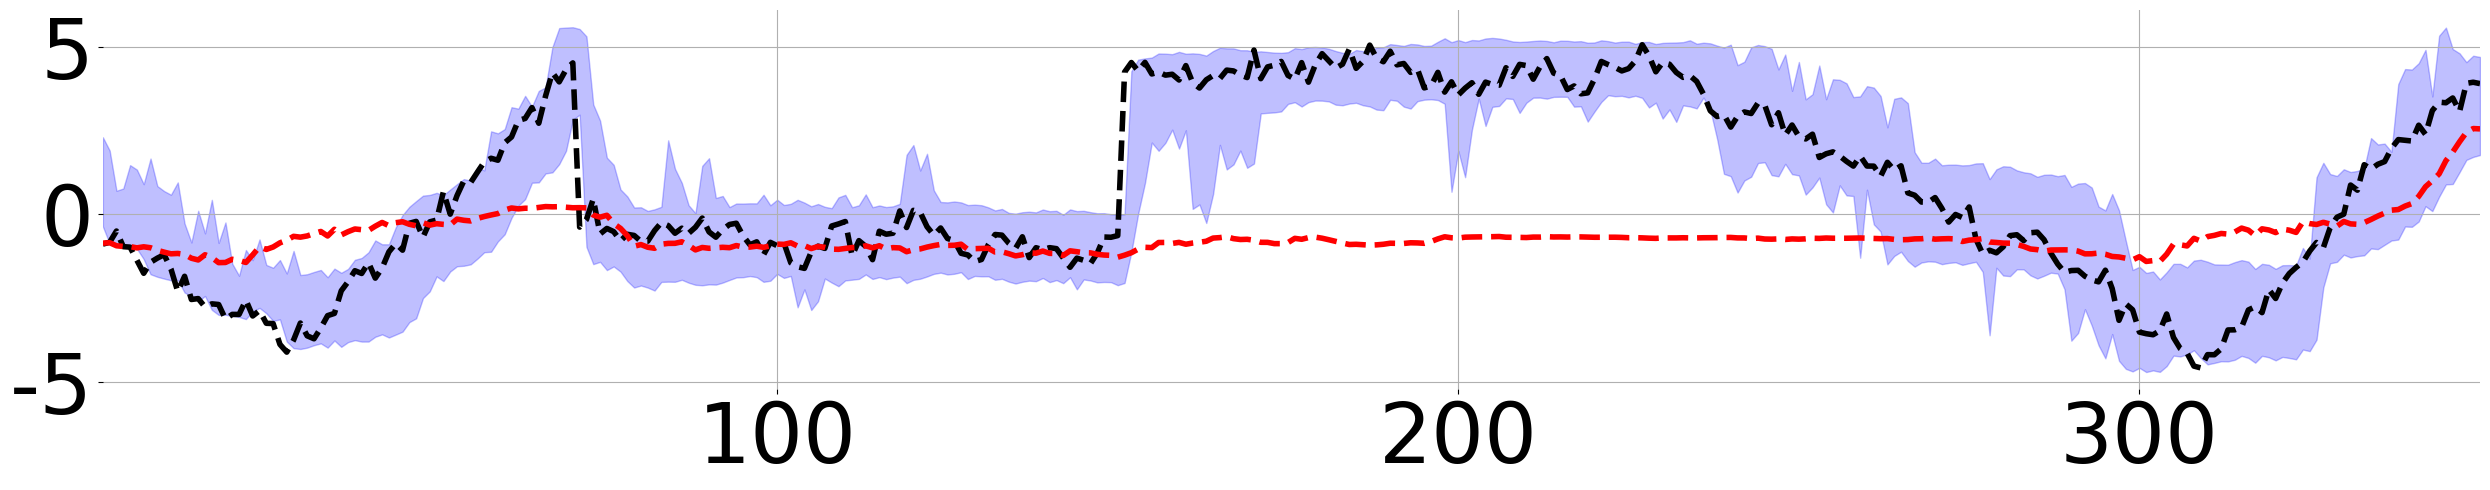

In [198]:
key = "darts_forest_dist_match_synthetic_s20_280126_163606"

result_df = get_df_by_key(key, file_idx=2, file_dir_getter=get_synthetic_file_dir)

fig, ax = plt.subplots(figsize=(25, 5))


ax = plot_data(ax, filter_df(result_df, 0, 1000), y_ticks=[-5, 0, 5], tick_step=100, labels_kw={"fontsize": 60})
fig.tight_layout()
fig.savefig(f"{key}.pdf")